In [1]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

In [2]:
train = pd.read_parquet('train.parquet')
val = pd.read_parquet('val.parquet')
test = pd.read_parquet('test.parquet')

target1 = 'Target1'
target2 = 'Target2'

In [3]:
for col in train.select_dtypes(include='number').columns:
    train[col].fillna(train[col].median(), inplace=True)

for col in train.select_dtypes(include='object').columns:
    train[col].fillna(train[col].mode()[0], inplace=True)




for col in val.select_dtypes(include='number').columns:
    val[col].fillna(val[col].median(), inplace=True)

for col in val.select_dtypes(include='object').columns:
    val[col].fillna(val[col].mode()[0], inplace=True)



for col in test.select_dtypes(include='number').columns:
    test[col].fillna(test[col].median(), inplace=True)

for col in test.select_dtypes(include='object').columns:
    test[col].fillna(test[col].mode()[0], inplace=True)

    


train_new = pd.get_dummies(train, drop_first=True)
val_new = pd.get_dummies(val, drop_first=True)
test_new = pd.get_dummies(test, drop_first=True)

/var/folders/_k/vxqnb8117qb_1tpg9p98mtyc0000gn/T/ipykernel_43970/2452799383.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].median(), inplace=True)
/var/folders/_k/vxqnb8117qb_1tpg9p98mtyc0000gn/T/ipykernel_43970/2452799383.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

In [4]:
train_data = lgb.Dataset(train_new.drop(columns=[target1, target2]), label=train_new[target1])
val_data = lgb.Dataset(val_new.drop(columns=[target1, target2]), label=val_new[target1], reference=train_data)

params = {
    'objective': 'binary',           # Задача бинарной классификации
    'boosting_type': 'gbdt',         # Тип бустинга
    'learning_rate': 0.05,           # Скорость обучения
    'num_leaves': 31,                # Количество листьев в дереве решений
    'max_depth': -1,                 # Максимальная глубина дерева (-1 — не ограничено)
    'verbose': -1,                   
    'random_state': 42
}

model = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    num_boost_round=1000
)

Accuracy на тесте: 0.9231
              precision    recall  f1-score   support

           0       0.92      0.98      0.95    148281
           1       0.92      0.76      0.83     48815

    accuracy                           0.92    197096
   macro avg       0.92      0.87      0.89    197096
weighted avg       0.92      0.92      0.92    197096

ROC-AUC Score на тесте: 0.9673


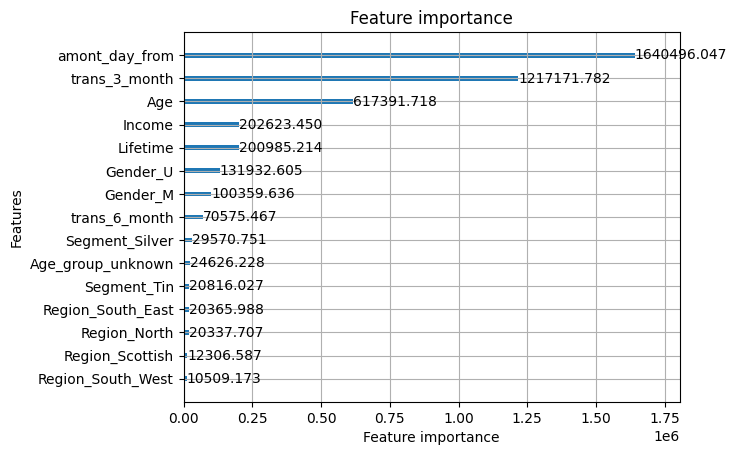

In [5]:
y_pred_prob = model.predict(test_new.drop(columns=[target1, target2]), num_iteration=model.best_iteration)
y_pred = (y_pred_prob > 0.5).astype(int)  # Преобразование вероятностей в метки классов

accuracy = accuracy_score(test_new[target1], y_pred)
print(f'Accuracy на тесте: {accuracy:.4f}')
print(classification_report(test_new[target1], y_pred))

lgb.plot_importance(model, max_num_features=15, importance_type='gain')

y_pred_prob = model.predict(test_new.drop(columns=[target1, target2]), num_iteration=model.best_iteration)

roc_auc = roc_auc_score(test_new[target1], y_pred_prob)
print(f'ROC-AUC Score на тесте: {roc_auc:.4f}')